In [35]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [11]:
import torch 
import torch.nn as nn

In [12]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [13]:
type(X_train_scaled)

numpy.ndarray

In [14]:
type(y_train)

pandas.Series

In [15]:
y_train.shape

(7654,)

In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Deep Learning

In [18]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            nn.Linear(6, 6),
            nn.ReLU(),

            nn.Linear(6, 1)
        )

    def forward(self, x):
            return self.model(x)

In [19]:
import torch.optim as optim 

In [20]:
model = ANN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

In [21]:
print(ANN.forward)
print(model.__class__)

<function ANN.forward at 0x000001ABFB91A520>
<class '__main__.ANN'>


In [22]:
train_losses = []
val_losses = [] 

best_val_loss = float("inf")

epochs = 100 

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train_loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train_loss = 205536.94869791667 & val_loss = 203465.03125
epoch 2/100 ==> train_loss = 196227.46223958334 & val_loss = 183981.609375
epoch 3/100 ==> train_loss = 160342.90908203126 & val_loss = 131034.1015625
epoch 4/100 ==> train_loss = 97980.00349934895 & val_loss = 67112.265625
epoch 5/100 ==> train_loss = 46168.6826171875 & val_loss = 31077.697265625
epoch 6/100 ==> train_loss = 24477.30830078125 & val_loss = 19873.486328125
epoch 7/100 ==> train_loss = 17649.785709635416 & val_loss = 15468.6337890625
epoch 8/100 ==> train_loss = 13892.041088867187 & val_loss = 12040.39453125
epoch 9/100 ==> train_loss = 10551.148046875 & val_loss = 8793.8193359375
epoch 10/100 ==> train_loss = 7467.16667175293 & val_loss = 5975.935546875
epoch 11/100 ==> train_loss = 5039.3214902242025 & val_loss = 4030.23486328125
epoch 12/100 ==> train_loss = 3458.3520584106445 & val_loss = 2776.587646484375
epoch 13/100 ==> train_loss = 2415.8741841634114 & val_loss = 1950.8106689453125
epoch 14

In [24]:
import matplotlib.pyplot as plt

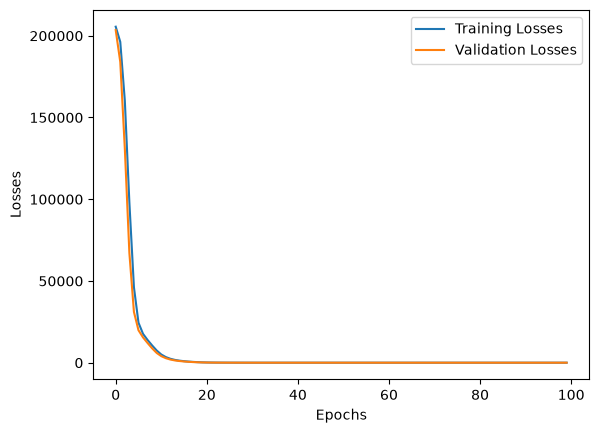

In [28]:
loss_df = ({
    "Training Losses": train_losses,
    "Validation Losses": val_losses
})

plt.plot(loss_df["Training Losses"], label = "Training Losses")
plt.plot(loss_df["Validation Losses"], label = "Validation Losses")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [29]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [31]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE", train_mse_loss.item())
print("Testing MSE", test_mse_loss.item())

Training MSE 20.170835494995117
Testing MSE 18.367233276367188


In [33]:
from sklearn.metrics import r2_score

print("R2 score", r2_score(y_test, test_preds))

R2 score 0.9358112655675922


In [37]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test, columns = ["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.722534,NaN
1,436.327118,NaN
2,461.025024,NaN
3,476.167328,NaN
4,434.680817,NaN
...,...,...
1909,451.010437,NaN
1910,431.001587,NaN
1911,467.455933,NaN
1912,430.403137,NaN
